# 策略 2：基于高频波动率因子的红利低波月调组合

本 notebook 在每月股息率前 150 名候选池内计算 20 个交易日的分钟波动率变异系数，并进行市值中性化；选择因子最低的 50 只股票按股息率加权。因子分组和 IC 也只针对该候选池，不代表研报的全 A 或完整红利股票池结果。

In [1]:
import os
import sys
from pathlib import Path

project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
os.chdir(project_root)
source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

In [2]:
from importlib.resources import files

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from pyquant import calc_metrics, load_dataset
from strategies.div_low_vol import (
    calculate_div_low_vol_monthly_rebalanced_index,
    calculate_high_frequency_div_low_vol_monthly_rebalanced_index,
    calculate_high_frequency_volatility_candidate_group_indices,
)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 配置与本地数据

In [3]:
with files("strategies.div_low_vol").joinpath("config.yaml").open(encoding="utf-8") as stream:
    config = yaml.safe_load(stream) or {}
start_date = pd.Timestamp(config["data"]["start_date"])
end_date = pd.Timestamp(config["data"]["end_date"])
lookback_date = start_date - pd.DateOffset(years=3)
feature_start = start_date - pd.Timedelta(days=60)

price = load_dataset("stock_daily", start=lookback_date.strftime("%Y-%m-%d"), end=end_date.strftime("%Y-%m-%d"))
dividends = load_dataset("dividend")
dividend_queries = load_dataset("dividend_queries")
shares = load_dataset("stock_profit_quarterly")
daily_volatility = load_dataset("intraday_volatility_daily", start=feature_start.strftime("%Y-%m-%d"), end=end_date.strftime("%Y-%m-%d"))
adjustment_factors = load_dataset("stock_adjust_factor")
adjustment_factor_coverage = load_dataset("stock_adjust_factor_coverage")
benchmark = load_dataset("csindex_daily", start=start_date.strftime("%Y-%m-%d"), end=end_date.strftime("%Y-%m-%d"), symbols=["H20269"]).set_index("date")["close"].rename("红利低波全收益指数")

## 高频波动率组合与基准

In [4]:
strategy_1_index, strategy_1_constituents = calculate_div_low_vol_monthly_rebalanced_index(price, dividends, dividend_queries, shares, start_date, end_date, config, adjustment_factors, adjustment_factor_coverage)
strategy_2_index, strategy_2_constituents = calculate_high_frequency_div_low_vol_monthly_rebalanced_index(price, dividends, dividend_queries, shares, daily_volatility, start_date, end_date, config, adjustment_factors, adjustment_factor_coverage)
candidate_factor_groups = calculate_high_frequency_volatility_candidate_group_indices(price, dividends, dividend_queries, shares, daily_volatility, start_date, end_date, config, adjustment_factors, adjustment_factor_coverage)

benchmark_monthly = benchmark.reindex(strategy_2_index.index).dropna()
curve = pd.concat([
    strategy_2_index["total_return_index"].rename("红利低波高频波动率月调组合"),
    strategy_1_index["total_return_index"].rename("红利低波普通月调组合"),
    benchmark_monthly,
], axis=1).dropna()
curve = curve.div(curve.iloc[0])
returns = curve.pct_change(fill_method=None).dropna()

## 收益曲线

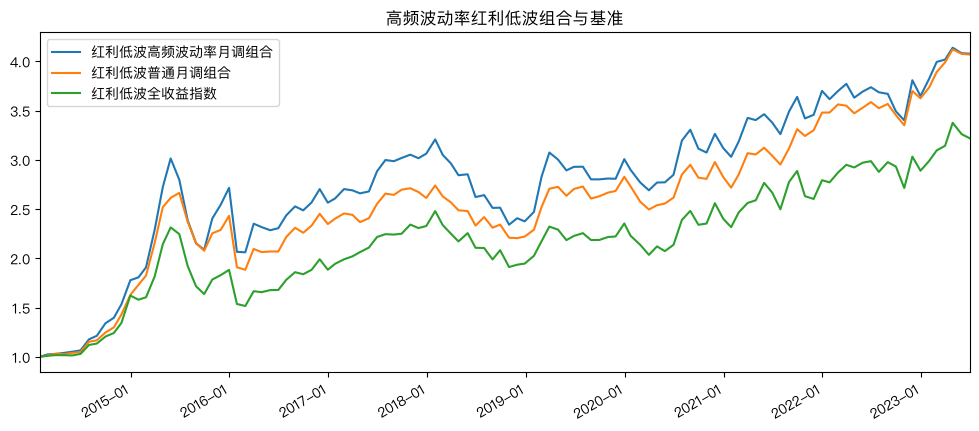

In [5]:
ax = curve.plot(figsize=(12, 5), title="高频波动率红利低波组合与基准")
ax.margins(x=0)
ax.set_xlabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend()
plt.show()

## 绩效对比

信息比率按年化收益除以年化波动计算；月度胜率为月收益大于零的比例。

In [6]:
def summarize_performance(monthly_returns):
    metrics = calc_metrics(monthly_returns, periods_per_year=12)
    return pd.Series({"年化收益": metrics["annual_return"], "年化波动": metrics["annual_vol"], "信息比率": metrics["sharpe"], "月度胜率": (monthly_returns > 0).mean(), "最大回撤": -metrics["max_drawdown"]})

performance = returns.apply(summarize_performance)
performance.style.format({"年化收益": "{:.2%}", "年化波动": "{:.2%}", "信息比率": "{:.2f}", "月度胜率": "{:.2%}", "最大回撤": "{:.2%}"})

,红利低波高频波动率月调组合,红利低波普通月调组合,红利低波全收益指数
年化收益,0.160959,0.160693,0.132156
年化波动,0.216606,0.182706,0.201022
信息比率,0.743097,0.879514,0.657424
月度胜率,0.601770,0.619469,0.619469
最大回撤,0.316104,0.293180,0.344779


## 候选池高频因子五分组

分组 1 为高频波动率最低组，分组 5 为最高组。该分组仅覆盖每月股息率前 150 名候选，不等同于研报的全 A 或完整红利股票池检验。

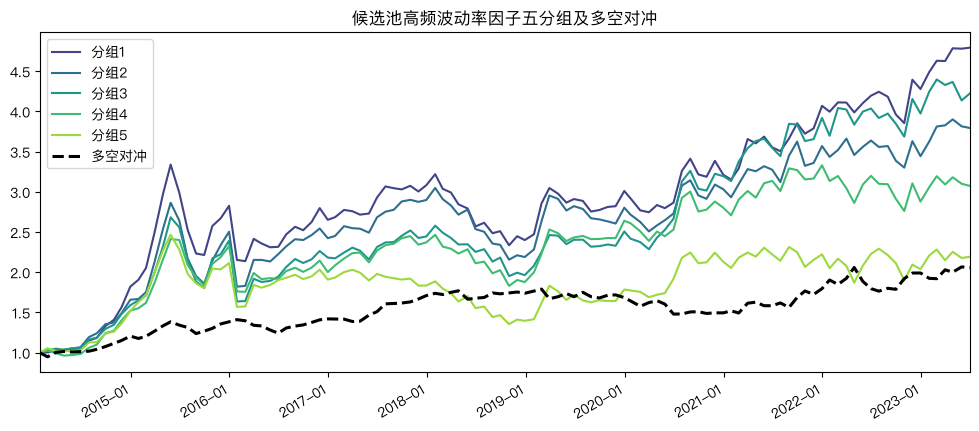

In [7]:
group_labels = ["分组1", "分组2", "分组3", "分组4", "分组5"]
group_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(group_labels)))
fig, ax = plt.subplots(figsize=(12, 5))
for column, label, color in zip(candidate_factor_groups.columns[:5], group_labels, group_colors):
    ax.plot(candidate_factor_groups.index, candidate_factor_groups[column], label=label, color=color)
ax.plot(candidate_factor_groups.index, candidate_factor_groups.iloc[:, -1], label="多空对冲", color="black", linestyle="--", linewidth=2.2)
ax.set_title("候选池高频波动率因子五分组及多空对冲")
ax.set_xlabel("")
ax.margins(x=0)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend()
fig.autofmt_xdate()
plt.show()

## 候选池因子表现与 IC

In [8]:
def annual_icir(ic):
    volatility = ic.std(ddof=1)
    return ic.mean() / volatility * np.sqrt(12) if volatility else np.nan

group_returns = candidate_factor_groups.iloc[:, :5].pct_change(fill_method=None).dropna()
factor_ic = candidate_factor_groups.attrs["factor_ic"].dropna()
group_metrics = calc_metrics(group_returns.iloc[:, 0], periods_per_year=12)
factor_performance = pd.Series({
    "年化收益": group_metrics["annual_return"],
    "年化波动": group_metrics["annual_vol"],
    "信息比率": group_metrics["sharpe"],
    "月度胜率": (group_returns.iloc[:, 0] > 0).mean(),
    "最大回撤": -group_metrics["max_drawdown"],
    "IC均值": factor_ic["ic"].mean(),
    "年化ICIR": annual_icir(factor_ic["ic"]),
    "Rank IC均值": factor_ic["rank_ic"].mean(),
    "年化Rank ICIR": annual_icir(factor_ic["rank_ic"]),
}, name="候选池高频波动率因子")
factor_performance

年化收益           0.181047
年化波动           0.227380
信息比率           0.796229
月度胜率           0.566372
最大回撤           0.359828
IC均值          -0.026004
年化ICIR        -0.726676
Rank IC均值     -0.051705
年化Rank ICIR   -1.474525
Name: 候选池高频波动率因子, dtype: float64